# Dataset overview & objective
Conjunto de datos: MovieLens ratings (ratings.dat). Cada fila representa la calificación que un usuario asignó a una película en una escala e 1 a 5.<br>
Problema: Regresión. El objetivo es predecir el valor numérico de la calificación que un usuario daría a una película.<br>
Características de entrada: user_id, movie_id (identificadores categóricos).<br>
Variable objetivo: rating.<br>
Este es un escenario clásico de sistemas de recomendación, donde el modelo aprende preferencias latentes a partir de interacciones históricas entre usuarios y películas.<br>

In [40]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

In [41]:
ratings_path = "data/ratings.dat"

ratings = pd.read_csv(
    ratings_path,
    sep="::",
    engine="python",
    names=["user_id", "movie_id", "rating", "timestamp"],
    usecols=[0, 1, 2],
)

ratings.head()

,user_id,movie_id,rating
0,1,1193,5
1,1,661,3
2,1,914,3
3,1,3408,4
4,1,2355,5


# Caracteristicas del dataset

In [42]:
print("Columns:", ratings.columns.tolist())
print("Rows:", len(ratings))
print("Users:", ratings["user_id"].nunique())
print("Movies:", ratings["movie_id"].nunique())
print("Ratings range:", (int(ratings["rating"].min()), int(ratings["rating"].max())))
print("Missing values:\n", ratings.isna().sum())
print("\nSample:\n", ratings.head(3))


Columns: ['user_id', 'movie_id', 'rating']
Rows: 1000209
Users: 6040
Movies: 3706
Ratings range: (1, 5)
Missing values:
 user_id     0
movie_id    0
rating      0
dtype: int64

Sample:
    user_id  movie_id  rating
0        1      1193       5
1        1       661       3
2        1       914       3


In [43]:
print("ratings:", ratings.shape)
print(ratings["rating"].describe())
print("unique users:", ratings["user_id"].nunique())
print("unique movies:", ratings["movie_id"].nunique())

total_possible = ratings["user_id"].nunique() * ratings["movie_id"].nunique()
print("sparsity:", 1 - (len(ratings) / total_possible))

ratings: (1000209, 3)
count    1.000209e+06
mean     3.581564e+00
std      1.117102e+00
min      1.000000e+00
25%      3.000000e+00
50%      4.000000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64
unique users: 6040
unique movies: 3706
sparsity: 0.9553163743776871


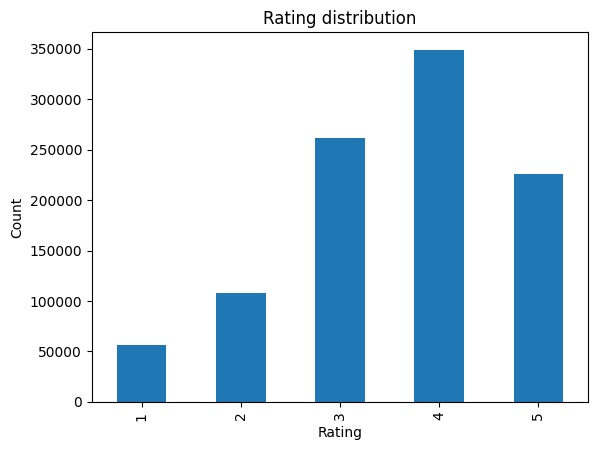

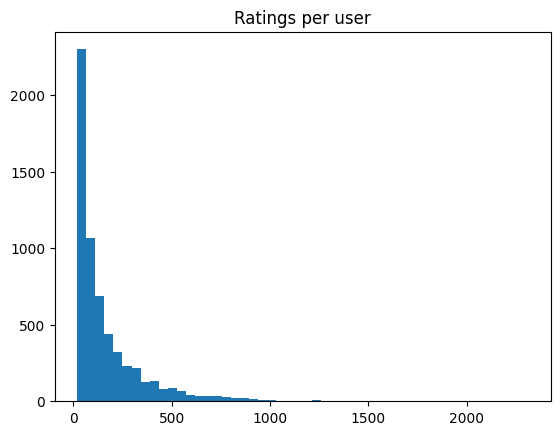

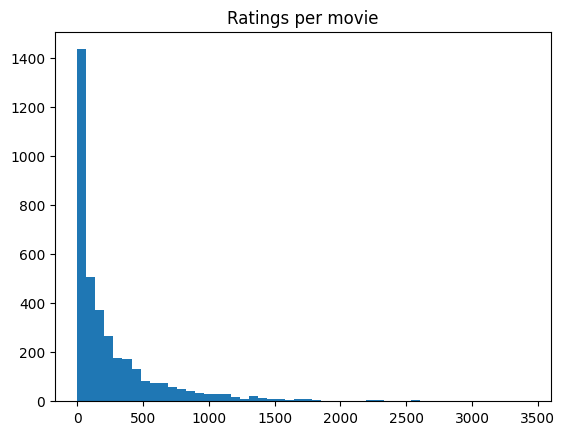

In [44]:
import matplotlib.pyplot as plt

plt.figure()
ratings["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Rating distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

ratings_per_user = ratings.groupby("user_id")["movie_id"].count()
ratings_per_movie = ratings.groupby("movie_id")["user_id"].count()

plt.figure()
plt.hist(ratings_per_user, bins=50)
plt.title("Ratings per user")
plt.show()

plt.figure()
plt.hist(ratings_per_movie, bins=50)
plt.title("Ratings per movie")
plt.show()


# Resumen del análisis exploratorio (EDA)

Las calificaciones se concentran en valores discretos entre 1 y 5 y el conjunto de datos es altamente disperso.
Solo una pequeña fracción de todas las combinaciones usuario–película tiene una calificación registrada, lo cual
justifica el uso de modelos de factorización de matrices con embeddings.


# Pipeline de preprocesamiento

Los identificadores originales `user_id` y `movie_id` se transforman en índices enteros consecutivos
(`user_idx`, `movie_idx`) para ser utilizados por las capas de embedding del modelo.
Este mapeo forma parte del pipeline de preprocesamiento y debe conservarse para garantizar inferencias consistentes.


In [45]:
user_ids = ratings["user_id"].unique()
movie_ids = ratings["movie_id"].unique()

user2idx = {int(u): i for i, u in enumerate(user_ids)}
movie2idx = {int(m): i for i, m in enumerate(movie_ids)}

df = pd.DataFrame({
    "user_idx": ratings["user_id"].map(user2idx).astype("int64"),
    "movie_idx": ratings["movie_id"].map(movie2idx).astype("int64"),
    "rating": ratings["rating"].astype("float32"),
})

df.head()

,user_idx,movie_idx,rating
0,0,0,5.0
1,0,1,3.0
2,0,2,3.0
3,0,3,4.0
4,0,4,5.0


In [46]:
def preprocess(ratings_df, user2idx, movie2idx):
    out = pd.DataFrame({
        "user_idx": ratings_df["user_id"].map(user2idx).astype("int64"),
        "movie_idx": ratings_df["movie_id"].map(movie2idx).astype("int64"),
        "rating": ratings_df["rating"].astype("float32"),
    })
    if out[["user_idx", "movie_idx", "rating"]].isna().any().any():
        raise ValueError("Found unmapped user_id/movie_id or missing values after preprocessing.")
    return out

_ = preprocess(ratings, user2idx, movie2idx)
print("Preprocess pipeline OK")


Preprocess pipeline OK


In [47]:
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42
)

print("Train size:", len(train_df))
print("Test size:", len(test_df))


Train size: 800167
Test size: 200042


In [48]:
class RatingsDataset(Dataset):
    def __init__(self, df):
        self.u = torch.tensor(df["user_idx"].values, dtype=torch.long)
        self.m = torch.tensor(df["movie_idx"].values, dtype=torch.long)
        self.y = torch.tensor(df["rating"].values, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.u[i], self.m[i], self.y[i]
class MF(nn.Module):
    def __init__(self, n_users, n_movies, k=32):
        super().__init__()
        self.user_emb = nn.Embedding(n_users, k)
        self.movie_emb = nn.Embedding(n_movies, k)
        self.user_bias = nn.Embedding(n_users, 1)
        self.movie_bias = nn.Embedding(n_movies, 1)

    def forward(self, user_idx, movie_idx):
        u = self.user_emb(user_idx)
        m = self.movie_emb(movie_idx)
        dot = (u * m).sum(dim=1)
        b = (self.user_bias(user_idx) + self.movie_bias(movie_idx)).squeeze(1)
        return dot + b


In [49]:
device = "cuda" if torch.cuda.is_available() else "cpu"

n_users = int(df["user_idx"].nunique())
n_movies = int(df["movie_idx"].nunique())

model = MF(n_users, n_movies, k=32).to(device)

train_loader = DataLoader(
    RatingsDataset(train_df), batch_size=4096, shuffle=True
)
test_loader = DataLoader(
    RatingsDataset(test_df), batch_size=4096, shuffle=False
)

optimizer = torch.optim.Adam(
    model.parameters(), lr=1e-2, weight_decay=1e-5
)
loss_fn = nn.MSELoss()


In [50]:
def rmse_on(loader):
    model.eval()
    se = 0.0
    n = 0
    with torch.no_grad():
        for u, m, y in loader:
            u, m, y = u.to(device), m.to(device), y.to(device)
            pred = model(u, m)
            se += ((pred - y) ** 2).sum().item()
            n += y.numel()
    return (se / n) ** 0.5

for epoch in range(1, 10):
    model.train()
    for u, m, y in train_loader:
        u, m, y = u.to(device), m.to(device), y.to(device)
        optimizer.zero_grad()
        pred = model(u, m)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()

    print(f"epoch {epoch} | test RMSE: {rmse_on(test_loader):.4f}")

epoch 1 | test RMSE: 3.7911
epoch 2 | test RMSE: 2.4549
epoch 3 | test RMSE: 1.8285
epoch 4 | test RMSE: 1.5091
epoch 5 | test RMSE: 1.3286
epoch 6 | test RMSE: 1.2167
epoch 7 | test RMSE: 1.1431
epoch 8 | test RMSE: 1.0922
epoch 9 | test RMSE: 1.0551


In [51]:
print("Final Train RMSE:", rmse_on(train_loader))
print("Final Test RMSE:", rmse_on(test_loader))

Final Train RMSE: 0.845684362630715
Final Test RMSE: 1.0550780866679377


In [55]:
import json
from pathlib import Path

import torch.onnx
import onnx
from onnx import external_data_helper

model.eval()

dummy_user = torch.zeros(1, dtype=torch.long).to(device)
dummy_movie = torch.zeros(1, dtype=torch.long).to(device)

Path("recommender.onnx").unlink(missing_ok=True)
Path("recommender.onnx.data").unlink(missing_ok=True)

torch.onnx.export(
    model,
    (dummy_user, dummy_movie),
    "recommender.onnx",
    input_names=["user_idx", "movie_idx"],
    output_names=["rating_pred"],
    dynamic_axes={
        "user_idx": {0: "batch"},
        "movie_idx": {0: "batch"},
        "rating_pred": {0: "batch"},
    },
    opset_version=18,
    do_constant_folding=True,
)

m = onnx.load("recommender.onnx", load_external_data=True)
external_data_helper.convert_model_from_external_data(m)
onnx.save(m, "recommender.onnx")

Path("recommender.onnx.data").unlink(missing_ok=True)

metadata = {
    "n_users": n_users,
    "n_movies": n_movies,
    "user2idx": user2idx,
    "movie2idx": movie2idx,
}

with open("metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f)

print("Saved single-file recommender.onnx and metadata.json")
print("External data file exists?:", Path("recommender.onnx.data").exists())


C:\Users\diego\AppData\Local\Temp\ipykernel_29428\4101024206.py:18: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0214 14:54:30.927000 29428 .venv\Lib\site-packages\torch\onnx\_internal\exporter\_registration.py:110] torchvision is not installed. Skipping torchvision::nms
W0214 14:54:30.928000 29428 .venv\Lib\site-packages\torch\onnx\_internal\exporter\_registration.py:110] torchvision is not installed. Skipping torchvision::roi_align
W0214 14:54:30.930000 29428 .venv\Lib\site-packages\torch\onnx\_internal\exporter\_registration.py:110] torchvision is not installed. Skipping torchvision::roi_pool


[torch.onnx] Obtain model graph for `MF([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MF([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Saved single-file recommender.onnx and metadata.json
External data file exists?: False


C:\Python314\Lib\copyreg.py:104: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
C:\Users\diego\PycharmProjects\Notebooks\.venv\Lib\site-packages\torch\onnx\_internal\exporter\_onnx_program.py:460: UserWarning: # The axis name: batch will not be used, since it shares the same shape constraints with another axis: batch.
  rename_mapping = _dynamic_shapes.create_rename_mapping(


# Uso del modelo en la aplicación

La aplicación de inferencia carga el modelo serializado en formato ONNX junto con el archivo `metadata.json`,
aplica el pipeline de preprocesamiento a los datos de entrada y ejecuta inferencia para obtener la calificación predicha.
